In [1]:
# 1. Primero instalamos e importamos lo necesario
!pip install pandas scikit-learn matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

print(" Librerías instaladas e importadas")

 Librerías instaladas e importadas


In [17]:
# 2. Descargamos y cargamos los datos
!wget -q https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv

bike_data = pd.read_csv("daily-bike-share.csv")
print("Datos cargados")
print(f"Dimensiones: {bike_data.shape}")

Datos cargados
Dimensiones: (731, 14)


In [18]:
# 3. Vemos cómo son los datos
print("Primeras 5 filas:")
print(bike_data.head())

Primeras 5 filas:
   instant    dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  1/1/2011       1   0     1        0        6           0   
1        2  1/2/2011       1   0     1        0        0           0   
2        3  1/3/2011       1   0     1        0        1           1   
3        4  1/4/2011       1   0     1        0        2           1   
4        5  1/5/2011       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  rentals  
0           2  0.344167  0.363625  0.805833   0.160446      331  
1           2  0.363478  0.353739  0.696087   0.248539      131  
2           1  0.196364  0.189405  0.437273   0.248309      120  
3           1  0.200000  0.212122  0.590435   0.160296      108  
4           1  0.226957  0.229270  0.436957   0.186900       82  


In [19]:
# 4. Información del dataset
print("\nInformación del dataset:")
bike_data.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  rentals     731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


In [20]:
# 5. Estadísticas básicas
print("\nEstadísticas descriptivas:")
print(bike_data[['temp', 'atemp', 'hum', 'windspeed', 'rentals']].describe())


Estadísticas descriptivas:
             temp       atemp         hum   windspeed      rentals
count  731.000000  731.000000  731.000000  731.000000   731.000000
mean     0.495385    0.474354    0.627894    0.190486   848.176471
std      0.183051    0.162961    0.142429    0.077498   686.622488
min      0.059130    0.079070    0.000000    0.022392     2.000000
25%      0.337083    0.337842    0.520000    0.134950   315.500000
50%      0.498333    0.486733    0.626667    0.180975   713.000000
75%      0.655417    0.608602    0.730209    0.233214  1096.000000
max      0.861667    0.840896    0.972500    0.507463  3410.000000


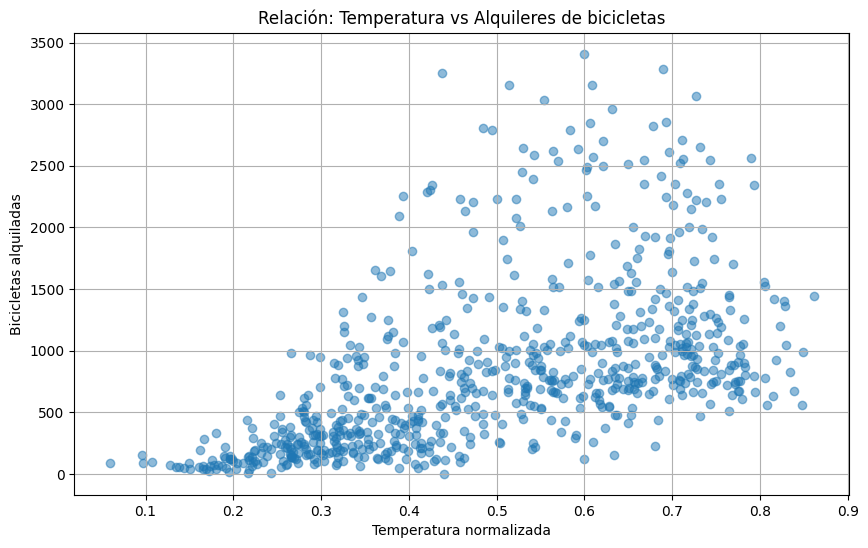

📈 Se observa relación lineal: más temperatura = más alquileres


In [8]:
# 6. Visualizamos la relación temperatura vs alquileres
plt.figure(figsize=(10, 6))
plt.scatter(bike_data['temp'], bike_data['rentals'], alpha=0.5)
plt.xlabel('Temperatura normalizada')
plt.ylabel('Bicicletas alquiladas')
plt.title('Relación: Temperatura vs Alquileres de bicicletas')
plt.grid(True)
plt.show()

print("📈 Se observa relación lineal: más temperatura = más alquileres")

In [21]:
# 7. Preparamos datos para el modelo
features = ['temp', 'atemp', 'hum', 'windspeed']
X = bike_data[features]
y = bike_data['rentals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(f"Datos divididos:")
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Datos divididos:
Entrenamiento: 511 filas
Prueba: 220 filas


In [11]:
# 8. Entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo entrenado")
print(f"Coeficientes: {model.coef_}")
print(f"Intercepto: {model.intercept_:.2f}")

✅ Modelo entrenado
Coeficientes: [ 1569.97528715   485.13296453  -617.30980711 -1290.73768019]
Intercepto: 468.43


In [12]:
# 9. Hacemos predicciones y evaluamos
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(" Resultados del modelo multivariable:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

📊 Resultados del modelo multivariable:
MSE: 354378.07
RMSE: 595.30


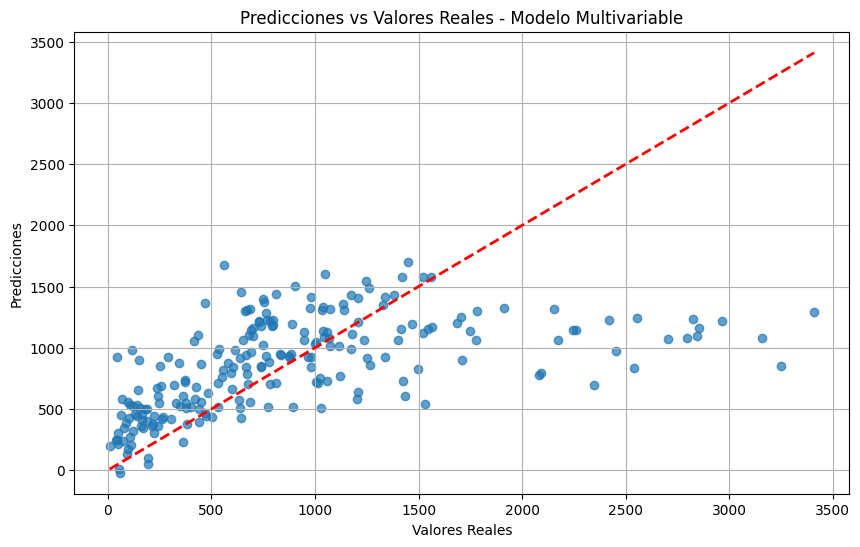

In [13]:
# 10. Graficamos predicciones vs reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales - Modelo Multivariable")
plt.grid(True)
plt.show()

In [15]:
# 11. Modelo solo con temperatura (comparación)
X_simple = bike_data[['temp']]
y_simple = bike_data['rentals']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.3, random_state=0)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print("📊 Resultados del modelo simple (solo temperatura):")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")

📊 Resultados del modelo simple (solo temperatura):
MSE: 374482.80
RMSE: 611.95


In [16]:
# 12. Comparación final
print("\n COMPARACIÓN FINAL:")
print(f"Modelo multivariable - RMSE: {rmse:.2f} bicicletas")
print(f"Modelo simple (solo temp) - RMSE: {rmse_simple:.2f} bicicletas")

if rmse < rmse_simple:
    print(" El modelo multivariable es MÁS preciso")
else:
    print(" El modelo simple es MÁS preciso")


 COMPARACIÓN FINAL:
Modelo multivariable - RMSE: 595.30 bicicletas
Modelo simple (solo temp) - RMSE: 611.95 bicicletas
 El modelo multivariable es MÁS preciso
